### 绘制PR曲线

In [1]:
import fiftyone as fo  

datasets_list = fo.list_datasets()
datasets_list

['my-dataset',
 'sahi_null_run_rawData_v4_jeff_0730-0813_01',
 'sahi_null_run_rawData_v4_ms1_0726-0809_11',
 'sahi_null_v2_ms1_0605-0621_40_ok',
 'sahi_null_v2_ms1_0710-0726_36_ok',
 'sahi_null_v2_ms1_0726-0809_11_ok',
 'sahi_null_v2_ms1_0809-0823_34_ok',
 'sahi_null_v2_ms2_0726-0809_13_ok',
 'sahi_null_v2_ms2_0809-0823_10_ok',
 'sahi_null_v2_sw1_0605-0613_07_ok',
 'sahi_null_v3_ms1_0605-0621_40_ok',
 'sahi_null_v3_ms1_0710-0726_36_ok',
 'sahi_null_v3_ms1_0726-0809_11_ok',
 'sahi_null_v3_ms1_0809-0823_34_ok',
 'sahi_null_v3_ms2_0726-0809_13_ok',
 'sahi_null_v3_ms2_0809-0823_10_ok',
 'sahi_null_v3_sw1_0605-0613_07_ok',
 'sahi_v1_ms1_0605-0621_40_ok',
 'sahi_v1_ms1_0710-0726_36_ok',
 'sahi_v1_ms1_0726-0809_11_ok',
 'sahi_v1_ms1_0809-0823_34_ok',
 'sahi_v1_ms2_0726-0809_13_ok',
 'sahi_v1_ms2_0809-0823_10_ok',
 'sahi_v1_sw1_0605-0613_07_ok',
 'v1_ms1_0710-0726_36_ok',
 'v1_ms1_0809-0823_34_ok',
 'v1_ms2_0726-0809_13_ok',
 'v1_sw1_0605-0613_07_ok',
 'v2_ms1_0605-0621_40_ok',
 'v2_ms1_0726-0

In [60]:

dataset_name = "sahi_null_v3_ms1_0726-0809_11_ok"
dataset = fo.load_dataset(dataset_name)

# 评估检测并计算mAP
results = dataset.evaluate_detections(
    "small_slices_yolo11x_20pct_null_images_add_rawData_batch_8_final", gt_field="ground_truth", method="coco", compute_mAP=True
)


Evaluating detections...
 100% |█████████████████| 464/464 [8.5s elapsed, 0s remaining, 37.8 samples/s]       
Performing IoU sweep...
 100% |█████████████████| 464/464 [8.8s elapsed, 0s remaining, 37.0 samples/s]       


In [61]:
# 检查评估结果是否有效  
print(f"Results type: {type(results)}")  
print(f"Classes: {results.classes}")  
print(f"Has confidence: {hasattr(results, 'confidence')}")  
  
# 检查数据是否存在  
if hasattr(results, 'precision'):  
    print(f"Precision shape: {results.precision.shape}")  
    print(f"Recall shape: {results.recall.shape}")

Results type: <class 'fiftyone.utils.eval.coco.COCODetectionResults'>
Classes: ['swd']
Has confidence: False
Precision shape: (10, 1, 101)
Recall shape: (101,)


Ignoring unsupported argument `thresholds` for the 'matplotlib' backend


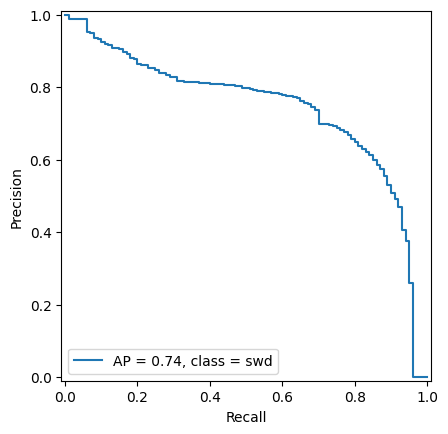

In [62]:
%matplotlib inline

plot = results.plot_pr_curves(backend="matplotlib", classes=["swd"])


Using IoU threshold: 0.5


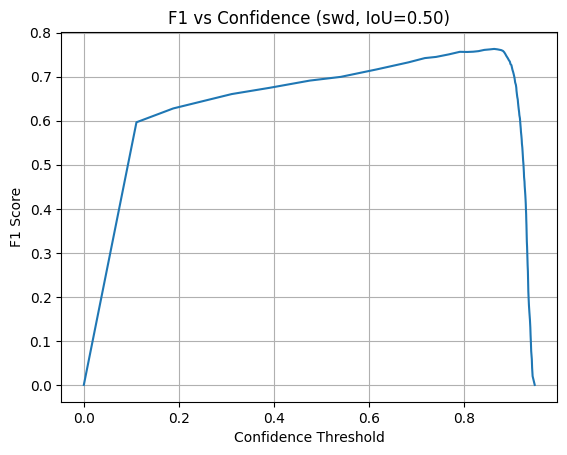

Best threshold: 0.8634328246116638
Best F1: 0.7631429316187321


In [64]:
import numpy as np
import matplotlib.pyplot as plt

class_name = "swd"
class_idx = np.where(results.classes == class_name)[0][0]

# ===== 找 IoU=0.5 index =====
iou_list = getattr(results, "iou_threshs", None)
if iou_list is None:
    iou_list = getattr(results, "iou_thresholds", None)

iou_list = np.array(iou_list)
iou_idx = np.argmin(np.abs(iou_list - 0.5))

print("Using IoU threshold:", iou_list[iou_idx])

# ===== 直接取 IoU=0.5 行 =====
P = results.precision[iou_idx, class_idx, :]   # (101,)
R = results.recall                              # (101,)
thr = results.thresholds[iou_idx, class_idx, :] # (101,)

# ===== F1 =====
F1 = 2 * P * R / (P + R + 1e-8)

# ===== Plot =====
plt.figure()
plt.plot(thr, F1)
plt.xlabel("Confidence Threshold")
plt.ylabel("F1 Score")
plt.title(f"F1 vs Confidence ({class_name}, IoU={iou_list[iou_idx]:.2f})")
plt.grid(True)
plt.show()

print("Best threshold:", thr[np.argmax(F1)])
print("Best F1:", np.max(F1))


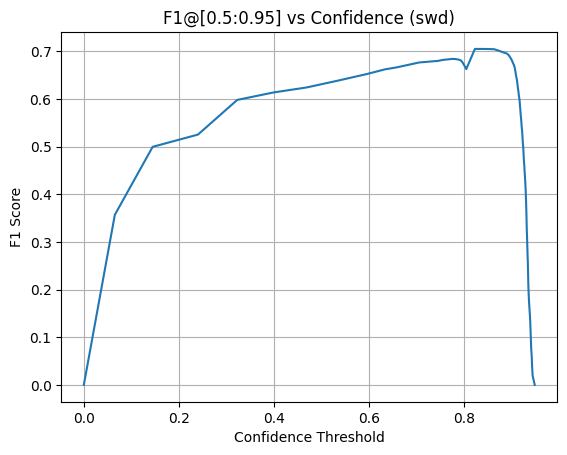

Best threshold: 0.8229013055562973
Best F1@[0.5:0.95]: 0.7053393154267487


In [65]:
import numpy as np
import matplotlib.pyplot as plt

class_name = "swd"
class_idx = np.where(results.classes == class_name)[0][0]

# ===== IoU list =====
iou_list = getattr(results, "iou_threshs", None)
if iou_list is None:
    iou_list = getattr(results, "iou_thresholds", None)

iou_list = np.array(iou_list)

# ===== Precision / Thresholds =====
# shape: (num_iou, num_classes, 101)
P_all = results.precision[:, class_idx, :]
thr_all = results.thresholds[:, class_idx, :]
R = results.recall   # (101,)

# ===== 逐 IoU 算 F1 =====
F1_all = []

for i in range(len(iou_list)):
    P_i = P_all[i]
    F1_i = 2 * P_i * R / (P_i + R + 1e-8)
    F1_all.append(F1_i)

F1_all = np.array(F1_all)   # (num_iou, 101)

# ===== COCO style mean =====
F1_mean = np.nanmean(F1_all, axis=0)

# threshold 也按 IoU 平均（这里只是用于画图）
thr_mean = np.nanmean(thr_all, axis=0)

# ===== Plot =====
plt.figure()
plt.plot(thr_mean, F1_mean)
plt.xlabel("Confidence Threshold")
plt.ylabel("F1 Score")
plt.title(f"F1@[0.5:0.95] vs Confidence ({class_name})")
plt.grid(True)
plt.show()

print("Best threshold:", thr_mean[np.argmax(F1_mean)])
print("Best F1@[0.5:0.95]:", np.max(F1_mean))


### 隔壁临时放这

Found datasets: 7
 - sahi_null_run_rawData_v4_jeff_0613-0624_04_ok
 - sahi_null_run_rawData_v4_jeff_0730-0813_01
 - sahi_null_run_rawData_v4_ms1_0726-0809_11
 - sahi_null_run_rawData_v4_ms1_0809-0823_34
 - sahi_null_run_rawData_v4_ms2_0621-0710_01
 - sahi_null_run_rawData_v4_ms2_0726-0809_13
 - sahi_null_run_rawData_v4_ms2_0823-0906_07

[EXPORT] sahi_null_run_rawData_v4_jeff_0613-0624_04_ok | samples=1112


 100% |███████████████| 1112/1112 [163.8ms elapsed, 0s remaining, 6.8K samples/s]     

[EXPORT] sahi_null_run_rawData_v4_jeff_0730-0813_01 | samples=456
 100% |█████████████████| 456/456 [270.8ms elapsed, 0s remaining, 1.7K samples/s]       

[EXPORT] sahi_null_run_rawData_v4_ms1_0726-0809_11 | samples=1386
 100% |███████████████| 1386/1386 [259.4ms elapsed, 0s remaining, 5.3K samples/s]      

[EXPORT] sahi_null_run_rawData_v4_ms1_0809-0823_34 | samples=1743
 100% |███████████████| 1743/1743 [384.8ms elapsed, 0s remaining, 4.5K samples/s]      

[EXPORT] sahi_null_run_rawData_v4_ms2_0621-0710_01 | samples=1254
 100% |███████████████| 1254/1254 [64.1ms elapsed, 0s remaining, 19.6K samples/s] 

[EXPORT] sahi_null_run_rawData_v4_ms2_0726-0809_13 | samples=1713
 100% |███████████████| 1713/1713 [342.1ms elapsed, 0s remaining, 5.0K samples/s]      

[EXPORT] sahi_null_run_rawData_v4_ms2_0823-0906_07 | samples=1682
 100% |███████████████| 1682/1682 [339.2ms elapsed, 0s remaining, 5.0K samp

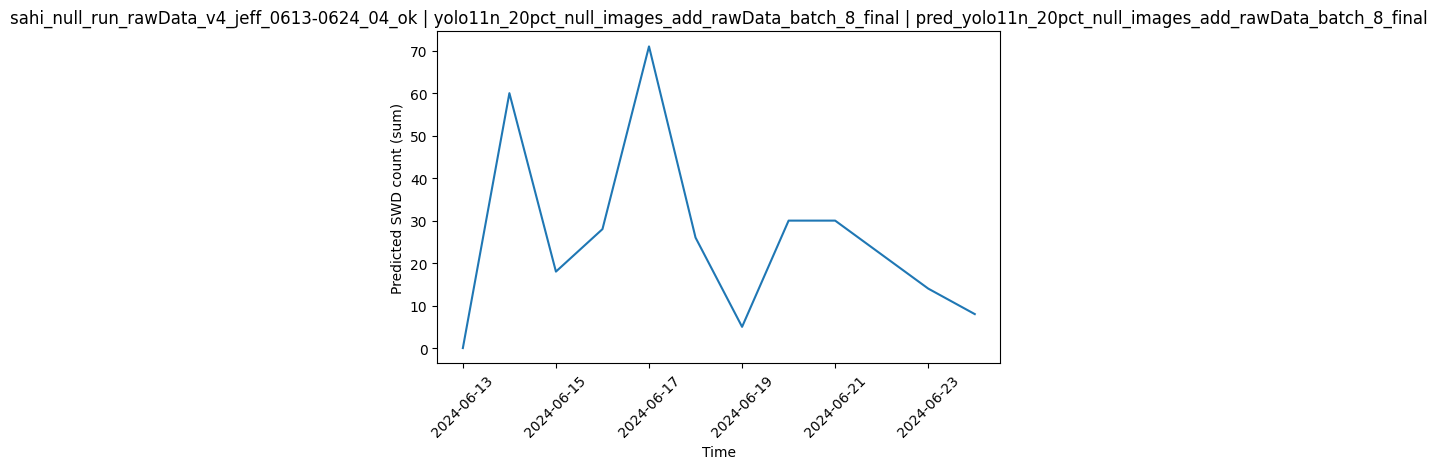

In [12]:
from __future__ import annotations

from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple
from datetime import datetime

import re
import numpy as np
import pandas as pd
import fiftyone as fo
import matplotlib.pyplot as plt


# =========================
# Config
# =========================
VERSION = "sahi_null_run_rawData_v4"
OUT_DIR = Path("./_pred_exports2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 你的预测时用的模型名（用来拼 pred_field）
MODEL_NAMES = [
    "yolo11n_20pct_null_images_add_rawData_batch_8_final.pt",
    # "yolo11x_20pct_null_images_add_rawData_batch_8_final.pt",
    # "yolo11m_20pct_null_images_add_rawData_batch_16_final.pt",
]

def model_tag_from_name(name: str) -> str:
    return Path(name).stem  # 你 pred_field 用 pred_{stem}

PRED_FIELDS = {model_tag_from_name(n): f"pred_{model_tag_from_name(n)}" for n in MODEL_NAMES}

# 文件名解析所需年份：0730_0602_580.jpg -> 2024-07-30 06:02
FILENAME_YEAR = 2024

# 时间聚合粒度：'D'按天，'H'按小时，'T'按分钟
TIME_FREQ = "D"

# 画图：是否按 focus 分线（focus 太多会很乱）
PLOT_BY_FOCUS = False


# 输出文件名
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_SUMMARY_XLSX   = OUT_DIR / f"pred_summary__{VERSION}__{stamp}.xlsx"
OUT_PER_IMAGE_XLSX = OUT_DIR / f"pred_per_image__{VERSION}__{stamp}.xlsx"
OUT_TS_XLSX        = OUT_DIR / f"pred_timeseries__{VERSION}__{stamp}.xlsx"


# =========================
# Helpers
# =========================
def safe_stats(confs: List[float]) -> Dict[str, float]:
    if not confs:
        return {"conf_max": np.nan, "conf_mean": np.nan, "conf_p50": np.nan, "conf_p90": np.nan}
    arr = np.asarray(confs, dtype=float)
    return {
        "conf_max": float(np.nanmax(arr)),
        "conf_mean": float(np.nanmean(arr)),
        "conf_p50": float(np.nanpercentile(arr, 50)),
        "conf_p90": float(np.nanpercentile(arr, 90)),
    }


def get_detections(sample: fo.Sample, pred_field: str):
    """安全拿 detections list"""
    if not sample.has_field(pred_field):
        return []
    val = sample[pred_field]  # 可能是 None / Detections
    if val is None:
        return []
    dets = getattr(val, "detections", None)
    return dets or []


# ---- filename parser: 0730_0602_580.jpg ----
FN_RE = re.compile(
    r"^(?P<mmdd>\d{4})_(?P<hhmm>\d{4})_(?P<focus>\d+)\.(jpg|jpeg|png)$",
    re.IGNORECASE,
)

def parse_time_focus(filename: str, year: int) -> Tuple[Optional[datetime], Optional[int], Optional[int]]:
    """
    0730_0602_580.jpg -> dt=2024-07-30 06:02, date_int=20240730, focus=580
    解析失败返回 (None, None, None)
    """
    m = FN_RE.match(filename)
    if not m:
        return None, None, None

    mmdd = m.group("mmdd")
    hhmm = m.group("hhmm")
    focus = int(m.group("focus"))

    month = int(mmdd[:2])
    day = int(mmdd[2:])
    hour = int(hhmm[:2])
    minute = int(hhmm[2:])

    try:
        dt = datetime(year, month, day, hour, minute)
    except ValueError:
        return None, None, None

    date_int = year * 10000 + month * 100 + day  # 20240730
    return dt, date_int, focus


def export_two_excels_for_dataset(
    ds: fo.Dataset,
    pred_fields: Dict[str, str],
    filename_year: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ds_name = ds.name
    n_samples = len(ds)

    summary_rows: List[Dict[str, Any]] = []
    per_image_rows: List[Dict[str, Any]] = []

    for model_tag, pred_field in pred_fields.items():
        if pred_field not in ds.get_field_schema():
            print(f"[WARN] {ds_name} missing pred_field={pred_field}, skip")
            continue

        total_pred = int(ds.count(f"{pred_field}.detections"))

        images_with_pred = 0
        confs_all: List[float] = []

        for sample in ds.iter_samples(progress=True):
            fn = Path(sample.filepath).name
            dt, date_int, focus = parse_time_focus(fn, filename_year)

            det_list = get_detections(sample, pred_field)
            n_det = len(det_list)

            if n_det > 0:
                images_with_pred += 1

            confs = [float(d.confidence) for d in det_list if d.confidence is not None]
            confs_all.extend(confs)

            row = {
                "dataset": ds_name,
                "sample_id": str(sample.id),
                "filepath": sample.filepath,
                "filename": fn,

                # 新增：时间 & focus
                "datetime": dt,          # datetime 类型（后面画图/聚合用）
                "date_int": date_int,    # 20240730
                "focus": focus,          # 580

                "model_tag": model_tag,
                "pred_field": pred_field,
                "pred_count": n_det,
            }
            row.update(safe_stats(confs))
            per_image_rows.append(row)

        s = {
            "dataset": ds_name,
            "model_tag": model_tag,
            "pred_field": pred_field,
            "num_samples": n_samples,
            "total_pred_count": total_pred,
            "images_with_pred": images_with_pred,
            "pct_images_with_pred": (images_with_pred / n_samples * 100.0) if n_samples else np.nan,
            "avg_pred_per_image": (total_pred / n_samples) if n_samples else np.nan,
        }
        s.update(safe_stats(confs_all))
        summary_rows.append(s)

    return pd.DataFrame(summary_rows), pd.DataFrame(per_image_rows)


def build_timeseries(df_per_image: pd.DataFrame, freq: str, plot_by_focus: bool) -> pd.DataFrame:
    """
    从 per-image 长表构建时间序列（按 dataset + model 聚合）
    输出列：
      - dataset, model_tag, pred_field, datetime, pred_count_sum
      (+ focus 如果 plot_by_focus)
    """
    if df_per_image.empty:
        return pd.DataFrame()

    df = df_per_image.copy()
    df = df[df["datetime"].notna()].copy()
    if df.empty:
        print("[WARN] All datetime parsing failed; check filename format")
        return pd.DataFrame()

    df["datetime"] = pd.to_datetime(df["datetime"])

    if plot_by_focus:
        ts = (
            df.set_index("datetime")
              .groupby(["dataset", "model_tag", "pred_field", "focus"])["pred_count"]
              .resample(freq)
              .sum()
              .reset_index()
              .rename(columns={"pred_count": "pred_count_sum"})
        )
    else:
        ts = (
            df.set_index("datetime")
              .groupby(["dataset", "model_tag", "pred_field"])["pred_count"]
              .resample(freq)
              .sum()
              .reset_index()
              .rename(columns={"pred_count": "pred_count_sum"})
        )

    return ts


def plot_timeseries(ts: pd.DataFrame, plot_by_focus: bool) -> None:
    """
    画一张“示例图”：
    - 默认取第一组 dataset+model（以及 focus）
    """
    if ts.empty:
        print("[WARN] timeseries is empty; nothing to plot")
        return

    plt.figure()

    if plot_by_focus:
        # 选第一组 dataset+model_tag+pred_field
        first = ts.iloc[0]
        ds0, mt0, pf0 = first["dataset"], first["model_tag"], first["pred_field"]
        sub = ts[(ts["dataset"] == ds0) & (ts["model_tag"] == mt0) & (ts["pred_field"] == pf0)]

        for f, g in sub.groupby("focus"):
            plt.plot(g["datetime"], g["pred_count_sum"], label=str(f))
        plt.legend(title="focus", loc="best")
        plt.title(f"{ds0} | {mt0} | {pf0}")
    else:
        first = ts.iloc[0]
        ds0, mt0, pf0 = first["dataset"], first["model_tag"], first["pred_field"]
        sub = ts[(ts["dataset"] == ds0) & (ts["model_tag"] == mt0) & (ts["pred_field"] == pf0)]
        plt.plot(sub["datetime"], sub["pred_count_sum"])
        plt.title(f"{ds0} | {mt0} | {pf0}")

    plt.xlabel("Time")
    plt.ylabel("Predicted SWD count (sum)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# =========================
# RUN
# =========================
all_summary = []
all_per_image = []

ds_names = sorted([n for n in fo.list_datasets() if n.startswith(f"{VERSION}_")])
print("Found datasets:", len(ds_names))
for n in ds_names:
    print(" -", n)

for ds_name in ds_names:
    ds = fo.load_dataset(ds_name)
    print(f"\n[EXPORT] {ds_name} | samples={len(ds)}")
    df_sum, df_img = export_two_excels_for_dataset(ds, PRED_FIELDS, FILENAME_YEAR)
    all_summary.append(df_sum)
    all_per_image.append(df_img)

df_summary = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()
df_per_image = pd.concat(all_per_image, ignore_index=True) if all_per_image else pd.DataFrame()

if not df_summary.empty:
    df_summary = df_summary.sort_values(["dataset", "model_tag"]).reset_index(drop=True)
if not df_per_image.empty:
    df_per_image = df_per_image.sort_values(["dataset", "model_tag", "filename"]).reset_index(drop=True)

# --- 保存两个 Excel ---
with pd.ExcelWriter(OUT_SUMMARY_XLSX, engine="openpyxl") as w:
    df_summary.to_excel(w, sheet_name="summary", index=False)

with pd.ExcelWriter(OUT_PER_IMAGE_XLSX, engine="openpyxl") as w:
    df_per_image.to_excel(w, sheet_name="per_image", index=False)

print("\nSaved:")
print(" -", OUT_SUMMARY_XLSX)
print(" -", OUT_PER_IMAGE_XLSX)
print("summary shape:", df_summary.shape, "| per_image shape:", df_per_image.shape)

# --- 构建时间序列 + 保存 + 画图 ---
ts = build_timeseries(df_per_image, freq=TIME_FREQ, plot_by_focus=PLOT_BY_FOCUS)

with pd.ExcelWriter(OUT_TS_XLSX, engine="openpyxl") as w:
    ts.to_excel(w, sheet_name=f"timeseries_{TIME_FREQ}", index=False)

print(" -", OUT_TS_XLSX, "| ts shape:", ts.shape)

plot_timeseries(ts, plot_by_focus=PLOT_BY_FOCUS)
